# Cross-Visit Generalization

**Cross-visit generalization**: Does a late-fusion model trained on visit-1 data predict visit-2 choices, vs. a model trained on visit-2 data itself (within-visit LOSO baseline)? If it does, decision signatures are stable traits. If not, strategies shifted between sessions.

**Data structure**: `user_id` in session_mapping is the desktop/hardware ID (only 3 unique values), not individual people. The real repeated unit is **team members** — a team of ~3 people returns for visit 2. All 34 visit-2 subject sessions come from the 12 teams that also had a visit-1 session. Each `subject_id` (mmdd_hhmm_userid) uniquely identifies one person's session.

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf

from src.utils.io import load_features

RESULTS_DIR = Path('../../data/results/main/cross_visit')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TIMEFRAME = 'PRE'
RANDOM_STATE = 42

## 1. Load Data

In [2]:
feature_data = load_features(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', timeframe=TIMEFRAME)

df = feature_data['merged_df'].copy()
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# Restrict to the 80-subject EEG set
EEG_ACC_PATH = '../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_subject_accuracies.csv'
eeg_subjects = set(pd.read_csv(EEG_ACC_PATH)['subject_id'])
df = df[df['subject_id'].isin(eeg_subjects)].copy()

# Add visit info from corrected session_mapping
sm = pd.read_csv('../../data/results/session_mapping.csv',
                 dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm['subject_id'] = sm['mmdd'] + '_' + sm['hhmm'] + '_' + sm['user_id']

df = df.merge(sm[['subject_id', 'visit_number', 'team']], on='subject_id', how='left')

print(f"Total trials: {len(df)}, subjects: {df['subject_id'].nunique()} (EEG set only)")
print("Trials per visit:")
print(df['visit_number'].value_counts().sort_index())
print(f"\nNaN visit: {df['visit_number'].isna().sum()} trials")

Total trials: 9618, subjects: 80 (EEG set only)
Trials per visit:
visit_number
1.0    4597
2.0    3704
3.0    1317
Name: count, dtype: int64

NaN visit: 0 trials


In [3]:
# Teams that appear in both visit 1 and visit 2
teams_v1 = set(sm[sm['visit_number'] == 1.0]['team'].dropna())
teams_v2 = set(sm[sm['visit_number'] == 2.0]['team'].dropna())
repeated_teams = sorted(teams_v1 & teams_v2)

print(f"Teams with visit 1 only: {len(teams_v1 - teams_v2)}")
print(f"Teams with both visit 1 and 2: {len(repeated_teams)}")
print(f"Repeated teams: {repeated_teams}")

v1 = df[df['visit_number'] == 1.0].copy()
v2 = df[df['visit_number'] == 2.0].copy()
v2_repeat = v2[v2['team'].isin(repeated_teams)].copy()

print(f"\nVisit 1: {v1['subject_id'].nunique()} subjects, {len(v1)} trials")
print(f"Visit 2 (repeated teams): {v2_repeat['subject_id'].nunique()} subjects, {len(v2_repeat)} trials")

Teams with visit 1 only: 6
Teams with both visit 1 and 2: 13
Repeated teams: ['Team 12', 'Team 15', 'Team 16', 'Team 17', 'Team 18', 'Team 20', 'Team 21', 'Team 22', 'Team 23', 'Team 24', 'Team 25', 'Team 26', 'Team 4']

Visit 1: 38 subjects, 4597 trials
Visit 2 (repeated teams): 31 subjects, 3704 trials


## 2. Cross-Visit Generalization

**Design**:
- **Baseline**: LOSO on visit-2 data only (how well can visit-2 subjects predict each other)
- **Cross-visit**: Train on all visit-1 data, test on each visit-2 subject individually
- **Oracle**: LOSO on visit-1 data (upper-bound reference)

If cross-visit ≈ baseline, decision signatures generalize across sessions. If cross-visit < baseline, the model needs to see visit-2 data to capture within-session drift.

In [4]:
def make_features(sub_df, physio_cols, behavior_cols, gaze_cols):
    imp = SimpleImputer(strategy='mean')
    X = imp.fit_transform(sub_df[physio_cols + behavior_cols + gaze_cols])
    y = sub_df['outcome'].values
    subjects = sub_df['subject_id'].values
    return X, y, subjects


def run_loso(X, y, subjects, random_state=RANDOM_STATE):
    logo = LeaveOneGroupOut()
    all_true, all_pred, subj_accs = [], [], []
    unique_subjs = np.unique(subjects)

    for train_idx, test_idx in logo.split(X, y, subjects):
        clf = RandomForestClassifier(
            n_estimators=100, class_weight='balanced',
            random_state=random_state, n_jobs=-1
        )
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[test_idx])
        all_true.extend(y[test_idx])
        all_pred.extend(pred)
        subj_accs.append({
            'subject_id': subjects[test_idx[0]],
            'accuracy': accuracy_score(y[test_idx], pred),
            'n_trials': len(test_idx)
        })

    return {
        'accuracy': accuracy_score(all_true, all_pred),
        'f1': f1_score(all_true, all_pred, average='weighted'),
        'subject_df': pd.DataFrame(subj_accs)
    }

In [5]:
# --- Oracle: LOSO on visit 1 ---
X1, y1, s1 = make_features(v1, physio_cols, behavior_cols, gaze_cols)
print("Running LOSO on visit 1 (oracle)...")
res_v1 = run_loso(X1, y1, s1)
print(f"  Visit 1 LOSO accuracy: {res_v1['accuracy']:.4f}, F1: {res_v1['f1']:.4f}")

# --- Baseline: LOSO on visit 2 ---
X2, y2, s2 = make_features(v2_repeat, physio_cols, behavior_cols, gaze_cols)
print("Running LOSO on visit 2 (baseline)...")
res_v2 = run_loso(X2, y2, s2)
print(f"  Visit 2 LOSO accuracy: {res_v2['accuracy']:.4f}, F1: {res_v2['f1']:.4f}")

Running LOSO on visit 1 (oracle)...
  Visit 1 LOSO accuracy: 0.7372, F1: 0.7250
Running LOSO on visit 2 (baseline)...
  Visit 2 LOSO accuracy: 0.7338, F1: 0.7019


In [6]:
# --- Cross-visit: train on visit 1, test each visit-2 subject ---
print("Running cross-visit (train V1 → test V2 subjects)...")

imp_full = SimpleImputer(strategy='mean')
X1_full = imp_full.fit_transform(v1[physio_cols + behavior_cols + gaze_cols])
y1_full = v1['outcome'].values

# Train one model on ALL visit-1 data
clf_cross = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
clf_cross.fit(X1_full, y1_full)

# Test on each visit-2 subject individually
cross_subj = []
imp_v2 = SimpleImputer(strategy='mean')
X2_full = imp_v2.fit_transform(v2_repeat[physio_cols + behavior_cols + gaze_cols])

for subj in v2_repeat['subject_id'].unique():
    mask = v2_repeat['subject_id'].values == subj
    y_s = v2_repeat['outcome'].values[mask]
    X_s = X2_full[mask]
    pred_s = clf_cross.predict(X_s)
    cross_subj.append({
        'subject_id': subj,
        'team': v2_repeat[v2_repeat['subject_id'] == subj]['team'].values[0],
        'accuracy_cross': accuracy_score(y_s, pred_s),
        'n_trials': len(y_s)
    })

cross_df = pd.DataFrame(cross_subj)
cross_acc_overall = accuracy_score(
    v2_repeat['outcome'].values,
    clf_cross.predict(X2_full)
)
print(f"  Cross-visit accuracy (aggregate): {cross_acc_overall:.4f}")
print(f"  Cross-visit accuracy (mean subject): {cross_df['accuracy_cross'].mean():.4f} ± {cross_df['accuracy_cross'].std():.4f}")

Running cross-visit (train V1 → test V2 subjects)...
  Cross-visit accuracy (aggregate): 0.7603
  Cross-visit accuracy (mean subject): 0.7645 ± 0.1480


In [7]:
# Merge cross-visit and within-v2 LOSO subject accuracies for comparison
compare_df = cross_df.merge(
    res_v2['subject_df'].rename(columns={'accuracy': 'accuracy_within_v2'}),
    on='subject_id'
)

compare_df['delta'] = compare_df['accuracy_cross'] - compare_df['accuracy_within_v2']

t_stat, p_val = stats.ttest_rel(compare_df['accuracy_cross'], compare_df['accuracy_within_v2'])
print(f"Paired t-test (cross-visit vs within-v2 LOSO): t={t_stat:.3f}, p={p_val:.4f}")
print(f"Mean delta (cross - within): {compare_df['delta'].mean():.4f} ± {compare_df['delta'].std():.4f}")
print(compare_df[['subject_id', 'team', 'accuracy_cross', 'accuracy_within_v2', 'delta', 'n_trials_x']].sort_values('delta').to_string())

Paired t-test (cross-visit vs within-v2 LOSO): t=2.850, p=0.0078
Mean delta (cross - within): 0.0261 ± 0.0510
           subject_id     team  accuracy_cross  accuracy_within_v2     delta  n_trials_x
27  0930_1700_9M4VCHG  Team 25        0.714286            0.803571 -0.089286         112
6   0823_1400_U9TEJGM  Team 15        0.569106            0.593496 -0.024390         123
7   0826_1300_539136F  Team 18        0.590909            0.613636 -0.022727         132
18  0917_1030_539136F  Team 22        0.618321            0.633588 -0.015267         131
3   0816_1400_U9TEJGM  Team 12        0.640000            0.648000 -0.008000         125
23  0923_1000_U9TEJGM  Team 23        0.765625            0.773438 -0.007812         128
22  0923_1000_9M4VCHG  Team 23        0.931298            0.938931 -0.007634         131
5   0823_1400_9M4VCHG  Team 15        0.992424            1.000000 -0.007576         132
19  0917_1030_9M4VCHG  Team 22        1.000000            1.000000  0.000000         129


In [8]:
# Also add visit-1 LOSO per-subject accuracy for the same teams
v1_team_subj = res_v1['subject_df'].copy()
v1_team_subj = v1_team_subj.merge(sm[['subject_id','team']], on='subject_id', how='left')
v1_repeated_teams_acc = v1_team_subj[v1_team_subj['team'].isin(repeated_teams)]

print("\nVisit-1 LOSO accuracy (repeated teams only):")
print(f"  Mean: {v1_repeated_teams_acc['accuracy'].mean():.4f} ± {v1_repeated_teams_acc['accuracy'].std():.4f}")
print(f"\nSummary table:")
print(f"  V1 LOSO (repeated teams): {v1_repeated_teams_acc['accuracy'].mean():.4f}")
print(f"  V2 LOSO (within-visit):   {res_v2['subject_df']['accuracy'].mean():.4f}")
print(f"  Cross-visit (V1→V2):      {cross_df['accuracy_cross'].mean():.4f}")


Visit-1 LOSO accuracy (repeated teams only):
  Mean: 0.7412 ± 0.1301

Summary table:
  V1 LOSO (repeated teams): 0.7412
  V2 LOSO (within-visit):   0.7383
  Cross-visit (V1→V2):      0.7645


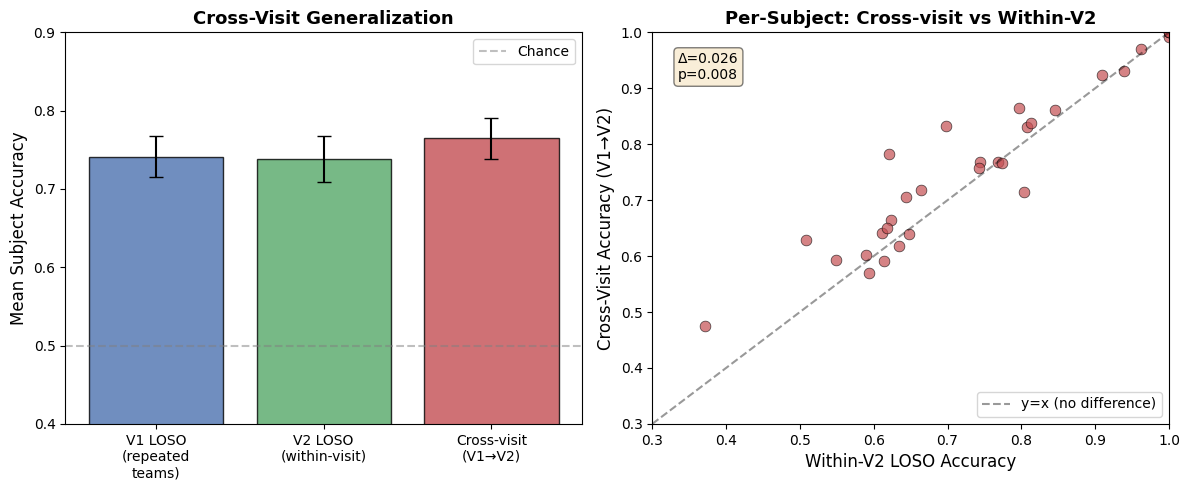

Saved figure.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: summary bar chart
ax = axes[0]
labels = ['V1 LOSO\n(repeated\nteams)', 'V2 LOSO\n(within-visit)', 'Cross-visit\n(V1→V2)']
means = [
    v1_repeated_teams_acc['accuracy'].mean(),
    res_v2['subject_df']['accuracy'].mean(),
    cross_df['accuracy_cross'].mean()
]
sems = [
    v1_repeated_teams_acc['accuracy'].sem(),
    res_v2['subject_df']['accuracy'].sem(),
    cross_df['accuracy_cross'].sem()
]
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(labels, means, yerr=sems, capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.set_ylabel('Mean Subject Accuracy', fontsize=12)
ax.set_title('Cross-Visit Generalization', fontsize=13, fontweight='bold')
ax.set_ylim(0.4, 0.9)
ax.legend()

# Panel B: subject-level scatter (cross-visit vs within-v2)
ax = axes[1]
ax.scatter(compare_df['accuracy_within_v2'], compare_df['accuracy_cross'],
           alpha=0.7, s=60, color='#C44E52', edgecolors='black', linewidth=0.5)
lims = [0.3, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.4, label='y=x (no difference)')
ax.set_xlabel('Within-V2 LOSO Accuracy', fontsize=12)
ax.set_ylabel('Cross-Visit Accuracy (V1→V2)', fontsize=12)
ax.set_title('Per-Subject: Cross-visit vs Within-V2', fontsize=13, fontweight='bold')
ax.set_xlim(lims)
ax.set_ylim(lims)

# Annotate with t-test
ax.text(0.05, 0.95, f'Δ={compare_df["delta"].mean():.3f}\np={p_val:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cross_visit_generalization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

### 2.1 V1→V2 Summary

In [10]:
print("=" * 60)
print("CROSS-VISIT GENERALIZATION")
print("=" * 60)
print(f"  V1 LOSO (oracle, repeated teams):  {v1_repeated_teams_acc['accuracy'].mean():.4f} ± {v1_repeated_teams_acc['accuracy'].sem():.4f}")
print(f"  V2 LOSO (within-visit baseline):   {res_v2['subject_df']['accuracy'].mean():.4f} ± {res_v2['subject_df']['accuracy'].sem():.4f}")
print(f"  Cross-visit (V1→V2):               {cross_df['accuracy_cross'].mean():.4f} ± {cross_df['accuracy_cross'].sem():.4f}")
print(f"  Δ cross - within: {compare_df['delta'].mean():.4f}, t={t_stat:.3f}, p={p_val:.4f}")

# Save summary
summary = {
    'v1_loso_acc': v1_repeated_teams_acc['accuracy'].mean(),
    'v2_loso_acc': res_v2['subject_df']['accuracy'].mean(),
    'cross_visit_acc': cross_df['accuracy_cross'].mean(),
    'cross_vs_within_delta': compare_df['delta'].mean(),
    'cross_vs_within_p': p_val,
}
pd.Series(summary).to_csv(RESULTS_DIR / 'summary.csv')
print(f"\nResults saved to {RESULTS_DIR}")

CROSS-VISIT GENERALIZATION
  V1 LOSO (oracle, repeated teams):  0.7412 ± 0.0260
  V2 LOSO (within-visit baseline):   0.7383 ± 0.0293
  Cross-visit (V1→V2):               0.7645 ± 0.0266
  Δ cross - within: 0.0261, t=2.850, p=0.0078

Results saved to ../../data/results/main/cross_visit


## 3. V1→V3 and V2→V3 Cross-Visit Generalization

V3 has 11 subjects from Teams 17, 21, 22, 24 — all four are repeated across all three visits in the EEG set.

**Design**:
- **Within-V3 LOSO**: baseline trained/tested only on V3 data
- **V1→V3**: train on all 38 V1 subjects, test each V3 subject
- **V2→V3**: train on V2 subjects from teams that also appear in V3, test each V3 subject

In [11]:
# V3 data and team overlaps
v3 = df[df['visit_number'] == 3.0].copy()

teams_v3 = set(v3['team'].dropna().unique())
teams_v1v3 = sorted(teams_v1 & teams_v3)
teams_v2v3 = sorted(teams_v2 & teams_v3)

print(f"V3 teams: {sorted(teams_v3)}")
print(f"Teams in both V1 and V3: {teams_v1v3}")
print(f"Teams in both V2 and V3: {teams_v2v3}")

# V2 subjects from teams that also appear in V3
v2_for_v3 = v2[v2['team'].isin(teams_v2v3)].copy()

print(f"\nV3: {v3['subject_id'].nunique()} subjects, {len(v3)} trials")
print(f"V1 (all): {v1['subject_id'].nunique()} subjects, {len(v1)} trials")
print(f"V2 (teams overlapping V3): {v2_for_v3['subject_id'].nunique()} subjects, {len(v2_for_v3)} trials")

V3 teams: ['Team 17', 'Team 21', 'Team 22', 'Team 24']
Teams in both V1 and V3: ['Team 17', 'Team 21', 'Team 22', 'Team 24']
Teams in both V2 and V3: ['Team 17', 'Team 21', 'Team 22', 'Team 24']

V3: 11 subjects, 1317 trials
V1 (all): 38 subjects, 4597 trials
V2 (teams overlapping V3): 8 subjects, 1016 trials


In [12]:
# --- Within-V3 LOSO baseline ---
X3, y3, s3 = make_features(v3, physio_cols, behavior_cols, gaze_cols)
print("Running within-V3 LOSO baseline...")
res_v3 = run_loso(X3, y3, s3)
print(f"  Within-V3 LOSO accuracy: {res_v3['accuracy']:.4f}, F1: {res_v3['f1']:.4f}")
print(f"  Per-subject mean: {res_v3['subject_df']['accuracy'].mean():.4f} ± {res_v3['subject_df']['accuracy'].sem():.4f}")

# --- V1→V3: train on all V1, test each V3 subject ---
print("\nRunning V1→V3 cross-visit...")
imp_v1 = SimpleImputer(strategy='mean')
X1_all = imp_v1.fit_transform(v1[physio_cols + behavior_cols + gaze_cols])
y1_all = v1['outcome'].values

clf_v1v3 = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
clf_v1v3.fit(X1_all, y1_all)

imp_v3 = SimpleImputer(strategy='mean')
X3_all = imp_v3.fit_transform(v3[physio_cols + behavior_cols + gaze_cols])

v1v3_subj = []
for subj in v3['subject_id'].unique():
    mask = v3['subject_id'].values == subj
    y_s = v3['outcome'].values[mask]
    X_s = X3_all[mask]
    pred_s = clf_v1v3.predict(X_s)
    v1v3_subj.append({
        'subject_id': subj,
        'team': v3[v3['subject_id'] == subj]['team'].values[0],
        'accuracy_v1v3': accuracy_score(y_s, pred_s),
        'n_trials': len(y_s)
    })
v1v3_df = pd.DataFrame(v1v3_subj)
print(f"  V1→V3 mean subject accuracy: {v1v3_df['accuracy_v1v3'].mean():.4f} ± {v1v3_df['accuracy_v1v3'].sem():.4f}")

# --- V2→V3: train on V2 (teams overlapping V3), test each V3 subject ---
print("\nRunning V2→V3 cross-visit...")
imp_v2f = SimpleImputer(strategy='mean')
X2f_all = imp_v2f.fit_transform(v2_for_v3[physio_cols + behavior_cols + gaze_cols])
y2f_all = v2_for_v3['outcome'].values

clf_v2v3 = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
clf_v2v3.fit(X2f_all, y2f_all)

# Reuse X3_all (already imputed on V3)
v2v3_subj = []
for subj in v3['subject_id'].unique():
    mask = v3['subject_id'].values == subj
    y_s = v3['outcome'].values[mask]
    X_s = X3_all[mask]
    pred_s = clf_v2v3.predict(X_s)
    v2v3_subj.append({
        'subject_id': subj,
        'team': v3[v3['subject_id'] == subj]['team'].values[0],
        'accuracy_v2v3': accuracy_score(y_s, pred_s),
        'n_trials': len(y_s)
    })
v2v3_df = pd.DataFrame(v2v3_subj)
print(f"  V2→V3 mean subject accuracy: {v2v3_df['accuracy_v2v3'].mean():.4f} ± {v2v3_df['accuracy_v2v3'].sem():.4f}")

Running within-V3 LOSO baseline...
  Within-V3 LOSO accuracy: 0.7388, F1: 0.7079
  Per-subject mean: 0.7446 ± 0.0504

Running V1→V3 cross-visit...
  V1→V3 mean subject accuracy: 0.7537 ± 0.0568

Running V2→V3 cross-visit...
  V2→V3 mean subject accuracy: 0.7389 ± 0.0579


In [13]:
# Paired comparisons for V1→V3 and V2→V3 vs within-V3 LOSO
v3_within = res_v3['subject_df'].rename(columns={'accuracy': 'accuracy_within_v3'})

compare_v1v3 = v1v3_df.merge(v3_within[['subject_id', 'accuracy_within_v3']], on='subject_id')
compare_v1v3['delta'] = compare_v1v3['accuracy_v1v3'] - compare_v1v3['accuracy_within_v3']
t_v1v3, p_v1v3 = stats.ttest_rel(compare_v1v3['accuracy_v1v3'], compare_v1v3['accuracy_within_v3'])

compare_v2v3 = v2v3_df.merge(v3_within[['subject_id', 'accuracy_within_v3']], on='subject_id')
compare_v2v3['delta'] = compare_v2v3['accuracy_v2v3'] - compare_v2v3['accuracy_within_v3']
t_v2v3, p_v2v3 = stats.ttest_rel(compare_v2v3['accuracy_v2v3'], compare_v2v3['accuracy_within_v3'])

print("=" * 65)
print("V3 CROSS-VISIT GENERALIZATION (N=11 subjects)")
print("=" * 65)
print(f"  Within-V3 LOSO:  {res_v3['subject_df']['accuracy'].mean():.4f} ± {res_v3['subject_df']['accuracy'].sem():.4f}")
print(f"  V1→V3 cross:     {v1v3_df['accuracy_v1v3'].mean():.4f} ± {v1v3_df['accuracy_v1v3'].sem():.4f}  "
      f"Δ={compare_v1v3['delta'].mean():.4f}, t={t_v1v3:.3f}, p={p_v1v3:.4f}")
print(f"  V2→V3 cross:     {v2v3_df['accuracy_v2v3'].mean():.4f} ± {v2v3_df['accuracy_v2v3'].sem():.4f}  "
      f"Δ={compare_v2v3['delta'].mean():.4f}, t={t_v2v3:.3f}, p={p_v2v3:.4f}")

print("\nPer-subject detail (V1→V3):")
print(compare_v1v3[['subject_id', 'team', 'accuracy_v1v3', 'accuracy_within_v3', 'delta']].sort_values('delta').to_string(index=False))
print("\nPer-subject detail (V2→V3):")
print(compare_v2v3[['subject_id', 'team', 'accuracy_v2v3', 'accuracy_within_v3', 'delta']].sort_values('delta').to_string(index=False))

V3 CROSS-VISIT GENERALIZATION (N=11 subjects)
  Within-V3 LOSO:  0.7446 ± 0.0504
  V1→V3 cross:     0.7537 ± 0.0568  Δ=0.0091, t=0.358, p=0.7276
  V2→V3 cross:     0.7389 ± 0.0579  Δ=-0.0057, t=-0.409, p=0.6911

Per-subject detail (V1→V3):
       subject_id    team  accuracy_v1v3  accuracy_within_v3     delta
0826_1000_9M4VCHG Team 17       0.574803            0.700787 -0.125984
0901_1300_9M4VCHG Team 21       0.354839            0.427419 -0.072581
0901_1300_U9TEJGM Team 21       0.648438            0.710938 -0.062500
0924_1000_539136F Team 22       0.703125            0.710938 -0.007812
0924_1000_9M4VCHG Team 22       0.984615            0.984615  0.000000
0924_1600_539136F Team 24       0.881356            0.881356  0.000000
0826_1000_539136F Team 17       0.984848            0.977273  0.007576
0924_1600_U9TEJGM Team 24       0.699187            0.682927  0.016260
0901_1300_539136F Team 21       0.887931            0.810345  0.077586
0924_1000_U9TEJGM Team 22       0.833333          

In [14]:
# Updated full summary table across all transfer directions
print("=" * 70)
print("COMPLETE CROSS-VISIT GENERALIZATION SUMMARY")
print("=" * 70)
print(f"\n--- V1→V2 (N=31 subjects) ---")
print(f"  Within-V2 LOSO:  {res_v2['subject_df']['accuracy'].mean():.4f} ± {res_v2['subject_df']['accuracy'].sem():.4f}")
print(f"  V1→V2 cross:     {cross_df['accuracy_cross'].mean():.4f} ± {cross_df['accuracy_cross'].sem():.4f}  "
      f"Δ={compare_df['delta'].mean():.4f}, t={t_stat:.3f}, p={p_val:.4f}")

print(f"\n--- V1→V3 (N=11 subjects) ---")
print(f"  Within-V3 LOSO:  {res_v3['subject_df']['accuracy'].mean():.4f} ± {res_v3['subject_df']['accuracy'].sem():.4f}")
print(f"  V1→V3 cross:     {v1v3_df['accuracy_v1v3'].mean():.4f} ± {v1v3_df['accuracy_v1v3'].sem():.4f}  "
      f"Δ={compare_v1v3['delta'].mean():.4f}, t={t_v1v3:.3f}, p={p_v1v3:.4f}")

print(f"\n--- V2→V3 (N=11 subjects) ---")
print(f"  Within-V3 LOSO:  {res_v3['subject_df']['accuracy'].mean():.4f} ± {res_v3['subject_df']['accuracy'].sem():.4f}")
print(f"  V2→V3 cross:     {v2v3_df['accuracy_v2v3'].mean():.4f} ± {v2v3_df['accuracy_v2v3'].sem():.4f}  "
      f"Δ={compare_v2v3['delta'].mean():.4f}, t={t_v2v3:.3f}, p={p_v2v3:.4f}")

# Save extended summary CSV
full_summary = {
    'v2_loso_acc': res_v2['subject_df']['accuracy'].mean(),
    'v1v2_cross_acc': cross_df['accuracy_cross'].mean(),
    'v1v2_delta': compare_df['delta'].mean(),
    'v1v2_p': p_val,
    'v3_loso_acc': res_v3['subject_df']['accuracy'].mean(),
    'v1v3_cross_acc': v1v3_df['accuracy_v1v3'].mean(),
    'v1v3_delta': compare_v1v3['delta'].mean(),
    'v1v3_p': p_v1v3,
    'v2v3_cross_acc': v2v3_df['accuracy_v2v3'].mean(),
    'v2v3_delta': compare_v2v3['delta'].mean(),
    'v2v3_p': p_v2v3,
}
pd.Series(full_summary).to_csv(RESULTS_DIR / 'summary_full.csv')

compare_v1v3.to_csv(RESULTS_DIR / 'cross_visit_v1v3_subject_accuracies.csv', index=False)
compare_v2v3.to_csv(RESULTS_DIR / 'cross_visit_v2v3_subject_accuracies.csv', index=False)
print(f"\nAll results saved to {RESULTS_DIR}")

COMPLETE CROSS-VISIT GENERALIZATION SUMMARY

--- V1→V2 (N=31 subjects) ---
  Within-V2 LOSO:  0.7383 ± 0.0293
  V1→V2 cross:     0.7645 ± 0.0266  Δ=0.0261, t=2.850, p=0.0078

--- V1→V3 (N=11 subjects) ---
  Within-V3 LOSO:  0.7446 ± 0.0504
  V1→V3 cross:     0.7537 ± 0.0568  Δ=0.0091, t=0.358, p=0.7276

--- V2→V3 (N=11 subjects) ---
  Within-V3 LOSO:  0.7446 ± 0.0504
  V2→V3 cross:     0.7389 ± 0.0579  Δ=-0.0057, t=-0.409, p=0.6911

All results saved to ../../data/results/main/cross_visit


## 4. Modality Ablation: Does Gaze Drive the V1→V2 Advantage?

Compare the V1→V2 generalization advantage under three feature sets:
- **Behavior-only**: no gaze, no physio
- **Gaze+behavior**: no physio
- **All features**: physio + behavior + gaze (original)

If gaze is responsible, the advantage (cross-visit − within-V2 LOSO) should shrink or disappear in the behavior-only condition.

In [15]:
def run_modality_ablation_v1v2(v1, v2_repeat, feature_sets, label):
    """Run cross-visit and within-V2 LOSO for a given feature column list."""
    imp1 = SimpleImputer(strategy='mean')
    X1 = imp1.fit_transform(v1[feature_sets])
    y1 = v1['outcome'].values

    imp2 = SimpleImputer(strategy='mean')
    X2 = imp2.fit_transform(v2_repeat[feature_sets])
    y2 = v2_repeat['outcome'].values
    s2 = v2_repeat['subject_id'].values

    # Within-V2 LOSO
    res_within = run_loso(X2, y2, s2)

    # Cross-visit: train on all V1, test each V2 subject
    clf = RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    clf.fit(X1, y1)

    cross_rows = []
    for subj in v2_repeat['subject_id'].unique():
        mask = v2_repeat['subject_id'].values == subj
        y_s = y2[mask]
        X_s = X2[mask]
        cross_rows.append({
            'subject_id': subj,
            'accuracy_cross': accuracy_score(y_s, clf.predict(X_s)),
        })
    cross_subj = pd.DataFrame(cross_rows)

    merged = cross_subj.merge(
        res_within['subject_df'].rename(columns={'accuracy': 'accuracy_within'}),
        on='subject_id'
    )
    merged['delta'] = merged['accuracy_cross'] - merged['accuracy_within']
    t, p = stats.ttest_rel(merged['accuracy_cross'], merged['accuracy_within'])

    return {
        'label': label,
        'n_features': len(feature_sets),
        'within_mean': merged['accuracy_within'].mean(),
        'within_sem': merged['accuracy_within'].sem(),
        'cross_mean': merged['accuracy_cross'].mean(),
        'cross_sem': merged['accuracy_cross'].sem(),
        'delta_mean': merged['delta'].mean(),
        'delta_sem': merged['delta'].sem(),
        't': t,
        'p': p,
        'subject_df': merged,
    }


feature_configs = {
    'behavior_only':   behavior_cols,
    'gaze+behavior':   gaze_cols + behavior_cols,
    'all_features':    physio_cols + behavior_cols + gaze_cols,
}

ablation_results = {}
for name, cols in feature_configs.items():
    print(f"Running {name} ({len(cols)} features)...")
    ablation_results[name] = run_modality_ablation_v1v2(v1, v2_repeat, cols, name)

print("\n" + "=" * 65)
print("MODALITY ABLATION: V1→V2 GENERALIZATION ADVANTAGE (N=31)")
print("=" * 65)
print(f"{'Modality':<20} {'Within-V2':>10} {'V1→V2':>10} {'Δ':>8} {'t':>7} {'p':>8}")
print("-" * 65)
for name, r in ablation_results.items():
    print(f"{name:<20} {r['within_mean']:.4f}±{r['within_sem']:.3f}  "
          f"{r['cross_mean']:.4f}±{r['cross_sem']:.3f}  "
          f"{r['delta_mean']:+.4f}  {r['t']:+.3f}  {r['p']:.4f}")


Running behavior_only (11 features)...
Running gaze+behavior (31 features)...
Running all_features (44 features)...

MODALITY ABLATION: V1→V2 GENERALIZATION ADVANTAGE (N=31)
Modality              Within-V2      V1→V2        Δ       t        p
-----------------------------------------------------------------
behavior_only        0.7182±0.030  0.7289±0.030  +0.0107  +1.073  0.2918
gaze+behavior        0.7401±0.029  0.7587±0.027  +0.0186  +1.787  0.0840
all_features         0.7383±0.029  0.7645±0.027  +0.0261  +2.850  0.0078


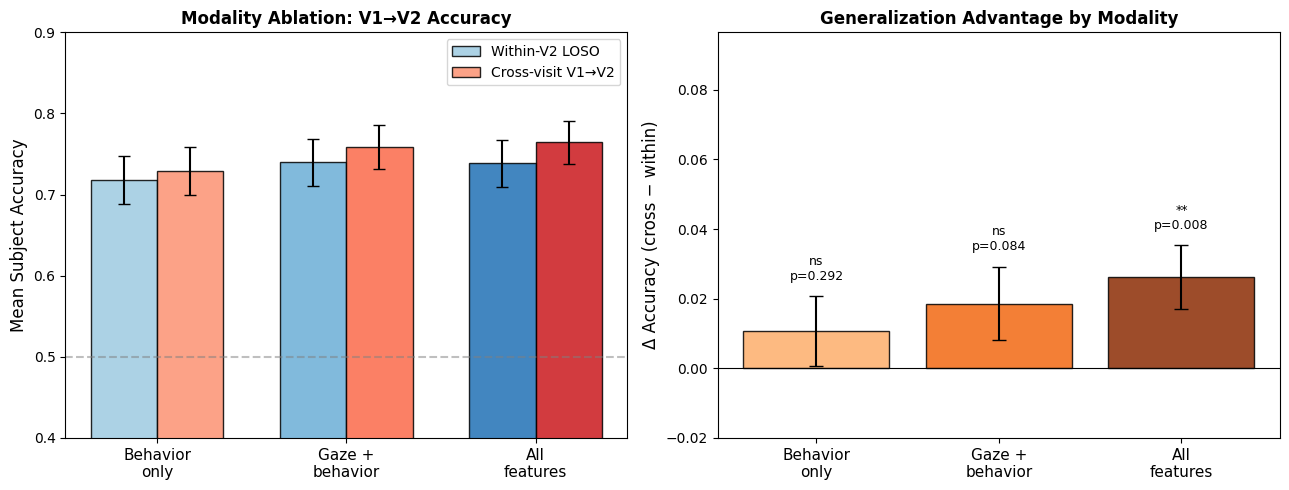

Saved figure.
     modality  n_features  within_mean  cross_mean  delta_mean  delta_sem        t        p
behavior_only          11     0.718200    0.728880    0.010680   0.009953 1.073038 0.291810
gaze+behavior          31     0.740057    0.758655    0.018598   0.010406 1.787252 0.084005
 all_features          44     0.738333    0.764451    0.026119   0.009164 2.850023 0.007830


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels_ordered = ['behavior_only', 'gaze+behavior', 'all_features']
display_labels = ['Behavior\nonly', 'Gaze +\nbehavior', 'All\nfeatures']
colors_within = ['#9ecae1', '#6baed6', '#2171b5']
colors_cross  = ['#fc9272', '#fb6a4a', '#cb181d']

# Panel A: grouped bar (within-V2 LOSO vs cross-visit) per modality set
ax = axes[0]
x = np.arange(len(labels_ordered))
w = 0.35
bars_w = ax.bar(x - w/2,
                [ablation_results[k]['within_mean'] for k in labels_ordered],
                w, yerr=[ablation_results[k]['within_sem'] for k in labels_ordered],
                capsize=4, label='Within-V2 LOSO', color=colors_within, alpha=0.85, edgecolor='black')
bars_c = ax.bar(x + w/2,
                [ablation_results[k]['cross_mean'] for k in labels_ordered],
                w, yerr=[ablation_results[k]['cross_sem'] for k in labels_ordered],
                capsize=4, label='Cross-visit V1→V2', color=colors_cross, alpha=0.85, edgecolor='black')

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=11)
ax.set_ylabel('Mean Subject Accuracy', fontsize=12)
ax.set_title('Modality Ablation: V1→V2 Accuracy', fontsize=12, fontweight='bold')
ax.set_ylim(0.4, 0.9)
ax.legend(fontsize=10)

# Panel B: generalization advantage (Δ = cross − within) per modality
ax = axes[1]
deltas = [ablation_results[k]['delta_mean'] for k in labels_ordered]
sems   = [ablation_results[k]['delta_sem']  for k in labels_ordered]
ps     = [ablation_results[k]['p']          for k in labels_ordered]
bar_colors = ['#fdae6b', '#f16913', '#8c2d04']

bars_d = ax.bar(x, deltas, yerr=sems, capsize=5,
                color=bar_colors, alpha=0.85, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)

for i, (d, s, p) in enumerate(zip(deltas, sems, ps)):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ypos = d + s + 0.004
    ax.text(i, ypos, f'{sig}\np={p:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=11)
ax.set_ylabel('Δ Accuracy (cross − within)', fontsize=12)
ax.set_title('Generalization Advantage by Modality', fontsize=12, fontweight='bold')
ax.set_ylim(-0.02, max(deltas) + max(sems) + 0.06)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'modality_ablation_v1v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

# Save per-subject delta CSVs for each modality
for name, r in ablation_results.items():
    r['subject_df'].assign(modality=name).to_csv(
        RESULTS_DIR / f'modality_ablation_{name}_subject_deltas.csv', index=False
    )

# Save summary row to CSV
ablation_summary = pd.DataFrame([
    {
        'modality': name,
        'n_features': r['n_features'],
        'within_mean': r['within_mean'],
        'cross_mean': r['cross_mean'],
        'delta_mean': r['delta_mean'],
        'delta_sem': r['delta_sem'],
        't': r['t'],
        'p': r['p'],
    }
    for name, r in ablation_results.items()
])
ablation_summary.to_csv(RESULTS_DIR / 'modality_ablation_summary.csv', index=False)
print(ablation_summary.to_string(index=False))
